# GLOBEC data

The U.S. GLOBal ocean ECosystems dynamics (GLOBEC) dataset here is organized from the BCO-DMO website and found by searching the key word 'Globec' in the database and then combing through the results for relevant data. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import geopandas as gpd
from datetime import datetime
import os
from matplotlib import ticker
import datetime as dt
import plotly.express as px
import cmocean as cm
import cmocean.cm as cmo
import matplotlib.gridspec as gridspec
import time
import matplotlib.ticker as mticker

In [2]:
bottle = pd.read_excel('bottle_data.xlsx')
bottle=bottle.rename(columns={'yr':'year','sta_std':'station_std','chl_a':'chl'})
bottle['datetime']= pd.to_datetime(bottle[['year', 'month', 'day']]) #datetime variable
bottle = bottle[bottle['chl_qcf'] != 1] #remove rows where control flag states bad chl
bottle['depth'] = bottle['pressure'] * 1.02 #convert pressure to depth 
bottle['HPLC'] = 1 #no hplc
#triplicate flag
counts_series = bottle[['depth','datetime','lat','lon']].value_counts() #count how many unique depth, datetime, lat, and lons there are
counts_df = counts_series.reset_index(name='freq_uniq')
bottle = pd.merge(bottle, counts_df, on=['depth','datetime','lat','lon'], how='left') #add frequency column to original dataframe
#sometimes, triplicate specific times are recorded (ex: 3:00, 3:05, 3:10 ), so also check for unique datehour entries
bottle['date_hour'] = bottle['datetime'].dt.strftime('%Y-%m-%d %H')
counts_series = bottle[['depth','date_hour','lat','lon']].value_counts() #count how many unique datehour, lat, and lons there are
counts_df = counts_series.reset_index(name='freq_hour')
bottle = pd.merge(bottle, counts_df, on=['depth','date_hour','lat','lon'], how='left') #add frequency column to original dataframe
bottle['triplicate'] = 1 #assume bad unless otherwise said
bottle.loc[bottle['freq_uniq'] == 3, 'triplicate'] = 0 #if there was a unique datetime, lat, and lon that happened 3 times, triplicate
bottle.loc[(bottle['freq_uniq'] == 1) &(bottle['freq_hour'] == 3), 'triplicate'] = 0 #if 1 unique datetime and 3 unique date_hours, assume triplicate

bottle=bottle[['datetime', 'cruise_id','station_std', 'lat', 'lon', 'chl', 'depth','HPLC','triplicate']]
bottle['project']='U.S. GLOBEC Northeast Pacific (NEP)'
bottle['source']='BCO-DMO'
bottle['contact']='Suzan S Pool'
bottle['affiliation']='Oregon State University'
bottle['url']='https://www.bco-dmo.org/dataset/2461'

FileNotFoundError: [Errno 2] No such file or directory: 'bottle_data.xlsx'

In [ ]:
nuts_chl = pd.read_excel('nuts_chl.xlsx')
nuts_chl = nuts_chl[nuts_chl['year'] >=2000] #for this specific algorithm, only keep dates from 2000 on
nuts_chl=nuts_chl.rename(columns={'month_gmt':'month','day_gmt':'day','time_gmt':'time','cruiseid':'cruise_id','chl_a':'chl'})
nuts_chl['time'] = [f"{int(t):04d}" for t in nuts_chl['time']]  #sometimes the leading 0s are removed, so pad until time is 4 integers long
nuts_chl['hour'] = [int(t[:2]) for t in nuts_chl['time']]
nuts_chl['minute'] = [int(t[2:4]) for t in nuts_chl['time']]
nuts_chl['datetime']= pd.to_datetime(nuts_chl[['year', 'month', 'day', 'hour','minute']]) 
nuts_chl['HPLC']=1 #no HPLC
nuts_chl['depth'] = nuts_chl['press'] * 1.02 #convert pressure to depth 
#triplicate flag
counts_series = nuts_chl[['depth','datetime','lat','lon']].value_counts()
counts_df = counts_series.reset_index(name='freq_uniq')
nuts_chl = pd.merge(nuts_chl, counts_df, on=['depth','datetime','lat','lon'], how='left') #add frequency column to original dataframe
nuts_chl['date_hour'] = nuts_chl['datetime'].dt.strftime('%Y-%m-%d %H')
counts_series = nuts_chl[['depth','date_hour','lat','lon']].value_counts() 
counts_df = counts_series.reset_index(name='freq_hour')
nuts_chl = pd.merge(nuts_chl, counts_df, on=['depth','date_hour','lat','lon'], how='left') #add frequency column to original dataframe
nuts_chl['triplicate'] = 1 #assume bad unless otherwise said
nuts_chl.loc[nuts_chl['freq_uniq'] == 3, 'triplicate'] = 0 
nuts_chl.loc[(nuts_chl['freq_uniq'] == 1) &(nuts_chl['freq_hour'] == 3), 'triplicate'] = 0
nuts_chl=nuts_chl[[ 'datetime','cruise_id', 'station_std', 'lat', 'lon', 'chl', 'HPLC', 'depth','triplicate']]
nuts_chl['project']='U.S. GLOBEC Northeast Pacific (NEP)'
nuts_chl['source']='BCO-DMO'
nuts_chl['contact']='Patricia Wheeler'
nuts_chl['affiliation']='Oregon State University'
nuts_chl['url']='https://www.bco-dmo.org/dataset/2456'

In [ ]:
phyto = pd.read_excel('phytoplankton.xlsx')
phyto=phyto.rename(columns={'month_utc':'month','day_utc':'day','time_utc':'time','cruise':'cruise_id', 'chl_a':'chl','chl_a_hplc':'chl_a'})
phyto['time'] = [f"{int(t):04d}" for t in phyto['time']]  
phyto['hour'] = [int(t[:2]) for t in phyto['time']]
phyto['minute'] = [int(t[2:4]) for t in phyto['time']]
phyto['datetime']= pd.to_datetime(phyto[['year', 'month', 'day', 'hour','minute']]) 
phyto = phyto[phyto['platform'] == 'ShipCTD']
#this dataset has both chlorophyll and HPLC chlorophyll (chl_a)
phyto['HPLC'] = 1 #initiate all points as no hplc
phyto.loc[phyto['chl_a'] != 'nd', 'HPLC'] = 0 #if hplc column is not empty, change to 0
#triplicate flag
counts_series = phyto[['depth','datetime','lat','lon']].value_counts() #count how many unique depth, datetime, lat, and lons there are
counts_df = counts_series.reset_index(name='freq_uniq')
phyto = pd.merge(phyto, counts_df, on=['depth','datetime','lat','lon'], how='left') #add frequency column to original dataframe
phyto['date_hour'] = phyto['datetime'].dt.strftime('%Y-%m-%d %H')
counts_series = phyto[['depth','date_hour','lat','lon']].value_counts() #count how many unique datehour, lat, and lons there are
counts_df = counts_series.reset_index(name='freq_hour')
phyto = pd.merge(phyto, counts_df, on=['depth','date_hour','lat','lon'], how='left') #add frequency column to original dataframe
phyto['triplicate'] = 1 #assume bad unless otherwise said
phyto.loc[phyto['freq_uniq'] == 3, 'triplicate'] = 0 #if there was a unique datetime, lat, and lon that happened 3 times, triplicate
phyto.loc[(phyto['freq_uniq'] == 1) &(phyto['freq_hour'] == 3), 'triplicate'] = 0
phyto=phyto[[ 'cruise_id','datetime','lat', 'lon',  'depth', 'chl', 'chl_a','HPLC','triplicate']]
phyto['project']='U.S. GLOBEC Northeast Pacific (NEP)'
phyto['source']='BCO-DMO'
phyto['contact']='Ricardo Letelier'
phyto['affiliation']='Oregon State University'
phyto['url']='https://www.bco-dmo.org/dataset/3097'

Concatinate the dataframes together, and then remove any repeat data found on SeaBASS


In [ ]:
globec = pd.concat([bottle,nuts_chl,phyto]).reset_index(drop=True)
globec = globec[globec['depth'] <=150] #for this algorithm, only keep epths above 150m

#SEABASS already has globec data, so compare and remove repeated data 
sb_west = pd.read_excel('allchl_SB_tripFLAGS.xlsx')
sb_west=sb_west[sb_west['experiment']=='GLOBEC'] #reduce to only GLOBEC data

sb_west=sb_west[['lat', 'lon', 'datetime','depth']]
#merge sb_west with globec on lat, lon, datetime, and depth
globec2 = globec.merge(sb_west[['datetime', 'lat', 'lon','depth']], on=['datetime', 'lat', 'lon','depth'], how='left', indicator=True) 
globec2 =  globec2[globec2['_merge'] != 'both'] #remove rows that are in both seabass and globec (i.e. seabass will keep the unique points)
globec2=globec2[['datetime', 'lat', 'lon', 'chl', 'chl_a','depth','cruise_id', 'station_std', 'HPLC', 'triplicate', 'project', 'source', 'contact', 
                 'affiliation', 'url']]
globec2 = globec2.rename(columns={'cruise_id': 'cruise','station_std':'station','project':'experiment','contact':'investigators','affiliation':'affiliations'})

globec2.loc[globec2['chl'].str.contains('nd', na=False), 'chl'] = np.nan #turn 'nd' to nan
globec2['chl'] = globec2['chl'].astype(float) 
globec2.loc[globec2['chl_a'].str.contains('nd', na=False), 'chl_a'] = np.nan
globec2['chl_a'] = globec2['chl_a'].astype(float) 

## plots

In [2]:
globec = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\globec_chl_qc.xlsx')


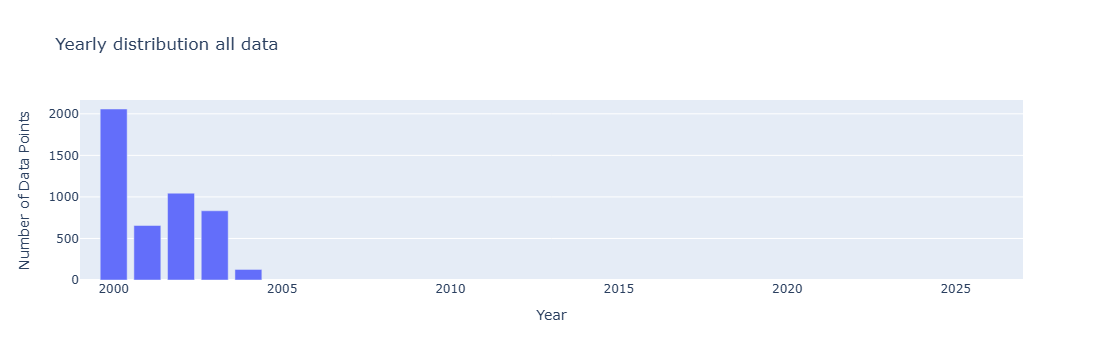

In [3]:
year_test=globec.copy()
year_test['datetime'] = pd.to_datetime(year_test['datetime'])
year_test['year'] = year_test['datetime'].dt.year
grouped = year_test.groupby(['year']).size().reset_index(name='DataPoints')

# Create bar chart
fig = px.bar(grouped,x='year', y='DataPoints', title='Yearly distribution all data',
             labels={'year': 'Year', 'DataPoints': 'Number of Data Points', 'metadata': 'Metadata'},)
fig.update_xaxes(range=[1999,2027])
fig.update_layout(barmode='stack')  # ensures stacking
fig.show()

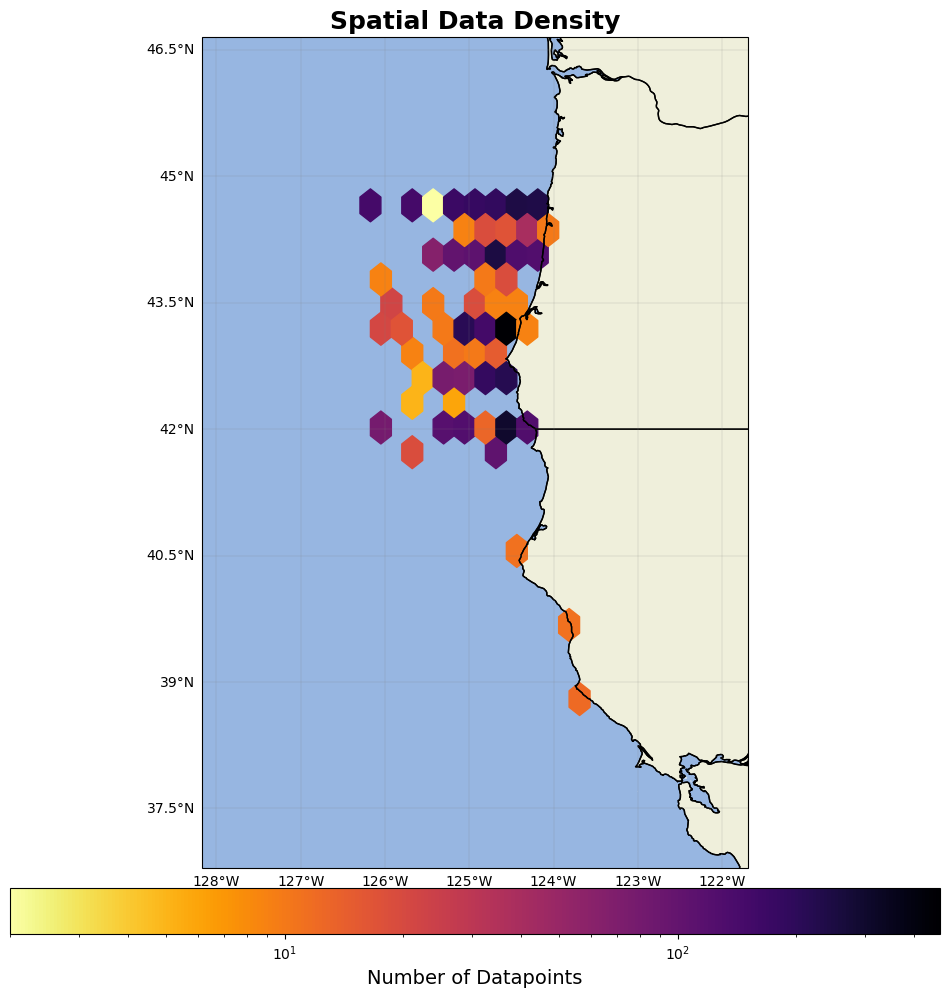

In [8]:
from matplotlib.colors import LogNorm # Important for high-variance data
fig = plt.figure(figsize=(15, 13))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)
hb = ax.hexbin(year_test.lon, year_test.lat, gridsize=(10,10), cmap='inferno_r', mincnt=1, transform=ccrs.PlateCarree(),norm=LogNorm()) 
cb = plt.colorbar(hb, ax=ax, orientation='horizontal', pad=0.02, shrink=0.8)
cb.set_label('Number of Datapoints', fontsize=14)
gl=ax.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
ax.set_xlim(min(year_test.lon)-2,max(year_test.lon)+2)
ax.set_ylim(min(year_test.lat)-2,max(year_test.lat)+2)

ax.set_title('Spatial Data Density', fontsize=18, fontweight='bold')

plt.show()
